In [2]:
import math
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.circuit import QuantumCircuit
import matplotlib.pyplot as plt

In [ ]:
qc = QuantumCircuit(3)
qc.h(0)

qc.h(1)
qc.s(1)

qc.h(2)
qc.t(2)
qc.barrier() 
qc.draw()

┌───┐      ░ 
q_0: ┤ H ├──────░─
     ├───┤┌───┐ ░ 
q_1: ┤ H ├┤ S ├─░─
     ├───┤├───┤ ░ 
q_2: ┤ H ├┤ T ├─░─
     └───┘└───┘ ░

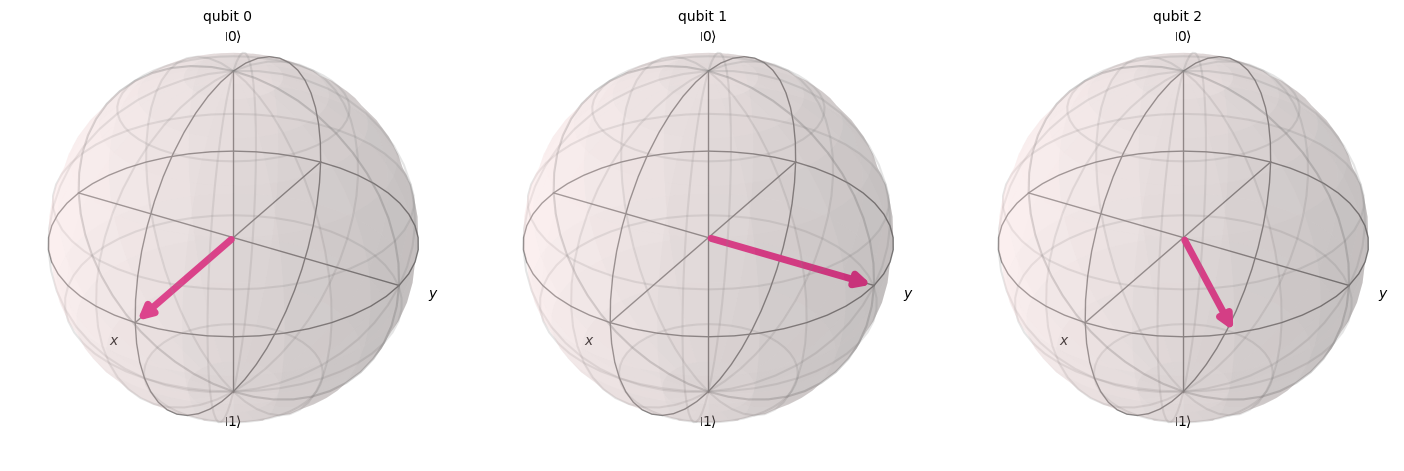

In [ ]:
state = Statevector(qc)
plot_bloch_multivector(state)


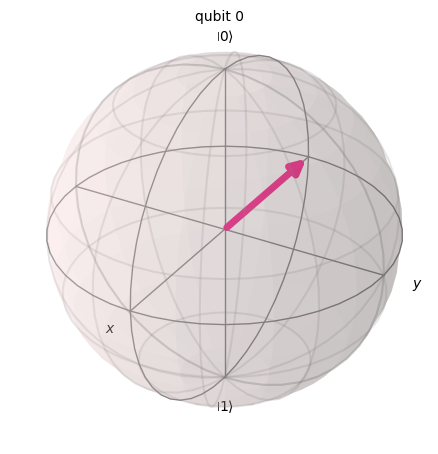

In [ ]:
# task day 2
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
s=Statevector(qc)
plot_bloch_multivector(s)


<h4>Day 3</h4>

In [ ]:
#task day 3
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
# qc.measure_all()
qc.draw()

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

In [ ]:
from qiskit_aer import AerSimulator
aer = AerSimulator()
x = aer.run(qc,shots = 1000)
result = x.result()
result

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='9d55988b-7f0f-4899-9060-04adfc07d7aa', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(), header={'creg_sizes': [], 'global_phase': 0.0, 'memory_slots': 0, 'n_qubits': 3, 'name': 'circuit-47', 'qreg_sizes': [['q', 3]], 'metadata': {}}, status=DONE, seed_simulator=3212781608, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 0, 'num_clbits': 0, 'time_taken': 0.0007163, 'input_qubit_map': [], 'max_memory_mb': 7959, 'measure_sampling': False, 'parallel_shots': 1, 'parallel_state_update': 8, 'runtime_parameter_bind': False, 'num_bind_params': 1}, time_taken=0.0007163)], date=2026-01-15T12:16:45.159437, status=COMPLETED, header=None, qobj_id='', metadata={'omp_enabled': True, 'parallel_experiments': 1, 'max_memory_mb': 7959, 'max_gpu_me

In [ ]:
result.results

[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(), header={'creg_sizes': [], 'global_phase': 0.0, 'memory_slots': 0, 'n_qubits': 3, 'name': 'circuit-47', 'qreg_sizes': [['q', 3]], 'metadata': {}}, status=DONE, seed_simulator=3212781608, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 0, 'num_clbits': 0, 'time_taken': 0.0007163, 'input_qubit_map': [], 'max_memory_mb': 7959, 'measure_sampling': False, 'parallel_shots': 1, 'parallel_state_update': 8, 'runtime_parameter_bind': False, 'num_bind_params': 1}, time_taken=0.0007163)]

In [ ]:
s = Statevector.from_instruction(qc)
s.draw(output="latex") 

<IPython.core.display.Latex object>

<h4>Day 4</h4>

In [ ]:
# day 4 task
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.z(0)
qc1.h(0)

s = Statevector(qc1) 
o = Operator(qc1)  
o.draw(output='latex')


<IPython.core.display.Latex object>

In [ ]:
s.draw(output="latex")

<IPython.core.display.Latex object>

In [ ]:
display(array_to_latex(o))

<IPython.core.display.Latex object>

In [ ]:
x = Statevector.from_int(2,8)
x.draw('latex')

<IPython.core.display.Latex object>

<h4>Day 5</h4>

In [ ]:
#using ScalarOp
from qiskit.quantum_info import ScalarOp
i = ScalarOp(3,4)
i.to_matrix()

array([[4.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 4.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 4.+0.j]])

In [ ]:
i.adjoint().to_matrix()

array([[4.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 4.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 4.+0.j]])

In [ ]:
other = ScalarOp(3,5)
other.to_matrix()

array([[5.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 5.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 5.+0.j]])

In [ ]:
i.compose(other).to_matrix()

array([[20.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, 20.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, 20.+0.j]])

In [ ]:
i.dot(other).to_matrix()

array([[20.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, 20.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, 20.+0.j]])

In [ ]:
i.expand(other).to_matrix()

array([[20.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j, 20.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, 20.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, 20.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, 20.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, 20.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, 20.+0.j,
         0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        20.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j, 20.+0.j]])

In [ ]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

obs = SparsePauliOp(['ZZ'])

estimator = StatevectorEstimator() 
job = estimator.run([(qc,obs)])
result = job.result()
result


PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>)), metadata={'target_precision': 0.0, 'circuit_metadata': {}})], metadata={'version': 2})

In [ ]:
result[0].metadata

{'target_precision': 0.0, 'circuit_metadata': {}}

In [ ]:
result[0].data.evs,result[0].data.stds

(array(1.), array(0.))

In [ ]:
# task day 5
qc = QuantumCircuit(1)
qc.h(0)

x = SparsePauliOp(['Z'])

estimator = StatevectorEstimator()
result = estimator.run([(qc,x)]).result() 

In [ ]:
result[0].data.evs,result[0].data.stds

(array(0.), array(0.))

<h5>Day 6</h5>

In [ ]:
from qiskit.circuit import Gate
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

x1 = qc.to_gate()
qc.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

In [ ]:
qc1 = QuantumCircuit(2)
qc1.append(x1,[0,1])
qc1.append(x1,[0,1])
qc1.draw()

┌─────────────┐┌─────────────┐
q_0: ┤0            ├┤0            ├
     │  circuit-64 ││  circuit-64 │
q_1: ┤1            ├┤1            ├
     └─────────────┘└─────────────┘

In [ ]:
p = qc1.decompose()
p.draw()

┌───┐     ┌───┐     
q_0: ┤ H ├──■──┤ H ├──■──
     └───┘┌─┴─┐└───┘┌─┴─┐
q_1: ─────┤ X ├─────┤ X ├
          └───┘     └───┘

In [ ]:
#controlled H gate
from qiskit.circuit.library import UnitaryGate 
import numpy as np

# defining gate using matrix
matrix = np.array([[1/np.sqrt(2),1/np.sqrt(2)],
          [1/np.sqrt(2),-1/np.sqrt(2)]]) 

h_gate = UnitaryGate(matrix)
qc1.append(h_gate,[[0,1]])
qc1.draw()

┌─────────────┐┌─────────────┐┌─────────┐
q_0: ┤0            ├┤0            ├┤ Unitary ├
     │  circuit-64 ││  circuit-64 │├─────────┤
q_1: ┤1            ├┤1            ├┤ Unitary ├
     └─────────────┘└─────────────┘└─────────┘

In [ ]:
#defining gate using Gate syntax
g = Gate('my_hadamard',1,[])
qc = QuantumCircuit(1)
qc.h(0) 

g.definition = qc 

In [ ]:
sub_h = QuantumCircuit(1)
sub_h.h(0)
custom_h = sub_h.to_gate()

c = QuantumCircuit(1)
c.append(custom_h,[0])
c.draw()

┌────────────┐
q: ┤ circuit-70 ├
   └────────────┘

In [ ]:
c_h_gate = custom_h.control(1)
c_h_gate

Instruction(name='ccircuit-70', num_qubits=2, num_clbits=0, params=[])

In [ ]:
sub_h = QuantumCircuit(2)
sub_h.append(c_h_gate,[0,1])
sub_h.draw()

q_0: ──────■───────
     ┌─────┴──────┐
q_1: ┤ circuit-70 ├
     └────────────┘

In [ ]:
# day 6 task
# from inbuilt function
qc = QuantumCircuit(3) 
bell_state = QuantumCircuit(2)
bell_state.h(0)
bell_state.cx(0,1) 
bell_gate = bell_state.to_gate() 
c_bell_gate = bell_gate.control(1)
qc.h(0)
qc.append(c_bell_gate,[0,1,2])
qc.measure_all()
qc.draw()  

┌───┐                ░ ┌─┐      
   q_0: ┤ H ├───────■────────░─┤M├──────
        └───┘┌──────┴──────┐ ░ └╥┘┌─┐   
   q_1: ─────┤0            ├─░──╫─┤M├───
             │  circuit-80 │ ░  ║ └╥┘┌─┐
   q_2: ─────┤1            ├─░──╫──╫─┤M├
             └─────────────┘ ░  ║  ║ └╥┘
meas: 3/════════════════════════╩══╩══╩═
                                0  1  2

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile
aer = AerSimulator() 
isa_qc = transpile(qc,backend=aer)
job = aer.run(isa_qc,shots = 1024)
result = job.result()
result.get_counts()

{'111': 237, '000': 531, '001': 256}

<h4>Day 7</h4>

In [ ]:
# teleportation implementation 
# on my own
from qiskit.circuit import QuantumCircuit
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator
from qiskit import transpile 

bell_state = QuantumCircuit(2) 
bell_state.h(0) 
bell_state.cx(0,1)
bell_gate = bell_state.to_gate() 

qc = QuantumCircuit(3,3)
qc.append(bell_gate,[1,2])
qc.h(0) 
qc.cx(0,1)
qc.h(0)
qc.measure(1,1)
qc.measure(0,0)
qc.measure(2,2)
qc.draw()

┌───┐          ┌───┐┌─┐
q_0: ─────┤ H ├───────■──┤ H ├┤M├
     ┌────┴───┴────┐┌─┴─┐└┬─┬┘└╥┘
q_1: ┤0            ├┤ X ├─┤M├──╫─
     │  circuit-88 │└┬─┬┘ └╥┘  ║ 
q_2: ┤1            ├─┤M├───╫───╫─
     └─────────────┘ └╥┘   ║   ║ 
c: 3/═════════════════╩════╩═══╩═
                      2    1   0

In [ ]:
backend = AerSimulator()
isa_qc = transpile(qc,backend=backend)
result = backend.run(isa_qc,shots = 100).result() 
result.get_counts()

{'100': 19,
 '001': 14,
 '111': 9,
 '010': 10,
 '000': 11,
 '011': 12,
 '110': 19,
 '101': 6}

In [ ]:
# gemini code
# 
from qiskit.circuit import QuantumCircuit
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator
from qiskit import transpile 

bell_state = QuantumCircuit(2) 
bell_state.h(0) 
bell_state.cx(0,1)
bell_gate = bell_state.to_gate() 

qc = QuantumCircuit(3,3)
qc.append(bell_gate,[1,2])
qc.h(0) 
qc.cx(0,1)
qc.h(0)
qc.measure(1,1)
qc.measure(0,0)
# qc.measure(2,2)
qc.draw()

┌───┐          ┌───┐┌─┐
q_0: ─────┤ H ├───────■──┤ H ├┤M├
     ┌────┴───┴────┐┌─┴─┐└┬─┬┘└╥┘
q_1: ┤0            ├┤ X ├─┤M├──╫─
     │  circuit-93 │└───┘ └╥┘  ║ 
q_2: ┤1            ├───────╫───╫─
     └─────────────┘       ║   ║ 
c: 3/══════════════════════╩═══╩═
                           1   0

In [ ]:
with qc.if_test((qc.clbits[0],1)):
    qc.z(2)
with qc.if_test((qc.clbits[1],1)):
    qc.x(2) 
qc.draw(output='text')

┌───┐          ┌───┐┌─┐                                          »
q_0: ─────┤ H ├───────■──┤ H ├┤M├──────────────────────────────────────────»
     ┌────┴───┴────┐┌─┴─┐└┬─┬┘└╥┘                                          »
q_1: ┤0            ├┤ X ├─┤M├──╫───────────────────────────────────────────»
     │  circuit-93 │└───┘ └╥┘  ║   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐»
q_2: ┤1            ├───────╫───╫───┤ If-0  ─┤ Z ├  End-0 ├───┤ If-0  ─┤ X ├»
     └─────────────┘       ║   ║   └──╥───  └───┘ ───────┘   └──╥───  └───┘»
                           ║   ║ ┌────╨────┐               ┌────╨────┐     »
c: 3/══════════════════════╩═══╩═╡ c_0=0x1 ╞═══════════════╡ c_1=0x1 ╞═════»
                           1   0 └─────────┘               └─────────┘     »
«               
«q_0: ──────────
«               
«q_1: ──────────
«      ───────┐ 
«q_2:   End-0 ├─
«      ───────┘ 
«c: 3/══════════
«

In [ ]:
qc.h(2)
qc.x(2)
qc.measure(2,2)

In [ ]:
backend = AerSimulator()
isa_qc = transpile(qc,backend=backend)
result = backend.run(isa_qc,shots = 100).result() 
result.get_counts()

{'110': 35, '111': 23, '101': 19, '100': 23}

In [ ]:
# task day 7
import numpy as np
qc = QuantumCircuit(3,3)
qc.ry(theta=np.pi/2,qubit=0) 
qc.append(bell_gate,[1,2])
qc.cx(0,1) 
qc.h(0) 
qc.measure(0,0)
qc.measure(1,1)
qc.draw() 


┌─────────┐       ┌───┐┌─┐
q_0: ──┤ Ry(π/2) ├────■──┤ H ├┤M├
     ┌─┴─────────┴─┐┌─┴─┐└┬─┬┘└╥┘
q_1: ┤0            ├┤ X ├─┤M├──╫─
     │  circuit-93 │└───┘ └╥┘  ║ 
q_2: ┤1            ├───────╫───╫─
     └─────────────┘       ║   ║ 
c: 3/══════════════════════╩═══╩═
                           1   0

In [ ]:

with qc.if_test((qc.clbits[0],1)):
    qc.z(2) 
with qc.if_test((qc.clbits[1],1)):
    qc.x(2)  


In [ ]:
# qc.h(2)
qc.ry(theta=-np.pi/2,qubit=2)
qc.measure(2,2) 

In [ ]:
backend = AerSimulator()
isa_qc = transpile(qc,backend=backend)
job = backend.run(isa_qc,shots=1000)
result = job.result()
result.get_counts()

{'000': 256, '011': 233, '001': 257, '010': 254}

<h4>Day 8</h4>

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(token="vVQPyZkLHpBBf2xFtR4C79C2OFJTwrrI9mNZ2_z_jhTO",
                               instance="crn:v1:bluemix:public:quantum-computing:us-east:a/2a11213c61e84a04944ce72c7ccb4e9c:13e4fe87-fd67-4d78-ac7d-6dcdb5b4562c::",
                               channel="ibm_cloud") 


In [ ]:
backend = service.least_busy()
backend.name

'ibm_fez'

In [ ]:
target = backend.target
target

In [ ]:
target.physical_qubits

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155]

In [ ]:
target.granularity

1

In [ ]:
target.num_qubits,target.dt,target.description,target.concurrent_measurements

(156, 4e-09, None, None)

In [ ]:
target.qubit_properties[0]

QubitProperties(t1=0.00005199156952582205, t2=0.00002253552085985709, frequency=None)

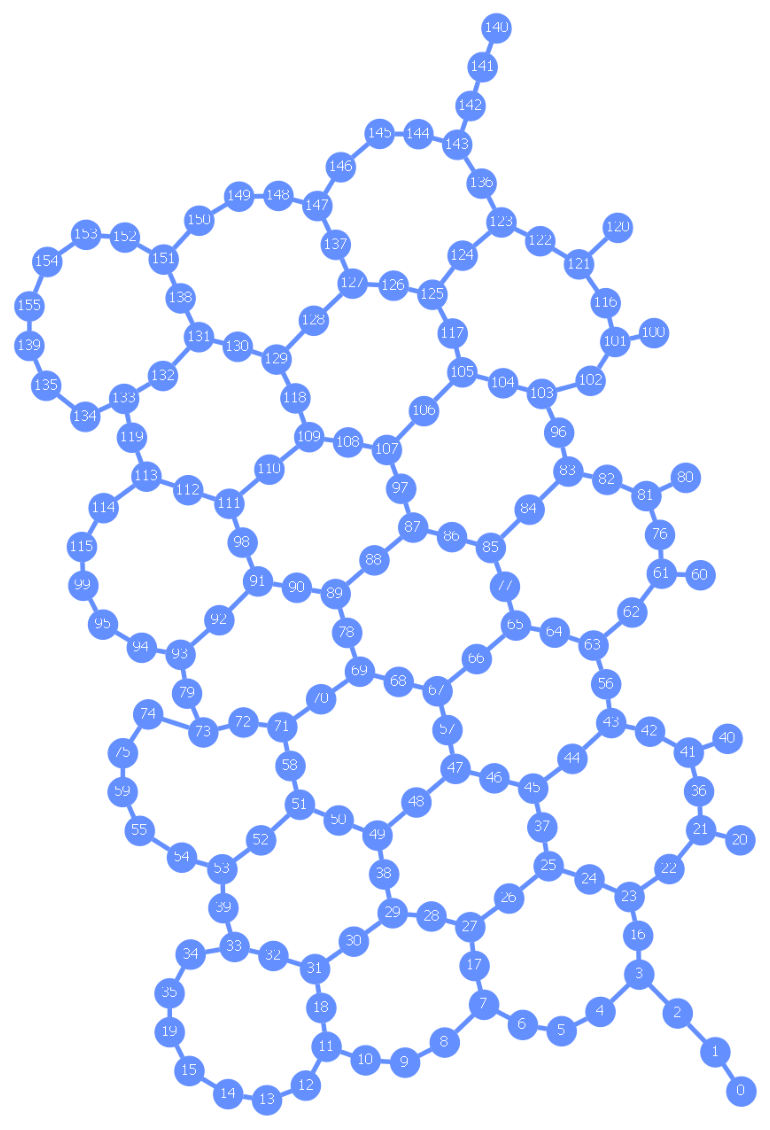

In [ ]:
from qiskit.visualization import plot_gate_map
plot_gate_map(backend) 

<h4>Day 9</h4>

In [ ]:
# finding error rate for 2 qubit bell state
from qiskit.circuit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2
from qiskit import transpile

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

backend = service.least_busy()
sampler = SamplerV2(backend)
isa_qc = transpile(qc,backend=backend)
isa_qc_pub = (isa_qc,None,100) 

job = sampler.run([isa_qc_pub])




In [ ]:
result = job.result() 
result[0]

SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=100, num_bits=2>)), metadata={'circuit_metadata': {}})

In [ ]:
for i in result[0].data:
    print(result[0].data[i])

BitArray(<shape=(), num_shots=100, num_bits=2>)


In [ ]:
result[0].data.meas.num_shots

100

In [ ]:
bits = result[0].data.meas
bits.get_bitstrings()

['00',
 '00',
 '00',
 '00',
 '11',
 '00',
 '00',
 '00',
 '00',
 '00',
 '00',
 '00',
 '10',
 '00',
 '11',
 '11',
 '00',
 '00',
 '11',
 '00',
 '11',
 '01',
 '00',
 '11',
 '11',
 '11',
 '00',
 '00',
 '11',
 '00',
 '00',
 '11',
 '00',
 '11',
 '11',
 '11',
 '11',
 '00',
 '00',
 '00',
 '00',
 '11',
 '11',
 '00',
 '00',
 '11',
 '11',
 '11',
 '11',
 '00',
 '11',
 '11',
 '11',
 '11',
 '11',
 '00',
 '00',
 '00',
 '00',
 '11',
 '00',
 '00',
 '00',
 '00',
 '00',
 '11',
 '00',
 '11',
 '11',
 '11',
 '00',
 '11',
 '11',
 '00',
 '00',
 '11',
 '11',
 '00',
 '11',
 '11',
 '00',
 '00',
 '11',
 '11',
 '00',
 '11',
 '00',
 '00',
 '00',
 '00',
 '00',
 '11',
 '11',
 '11',
 '11',
 '11',
 '00',
 '11',
 '00',
 '00']

In [ ]:
# the '01' and '10' are noise
counts = bits.get_counts()
error_rate = (counts['10'] + counts['01'])/100
error_rate

0.02

In [ ]:
bits.bitcount()

array([0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 2, 1,
       0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 0,
       0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2,
       0, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0,
       0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 0], dtype=uint64)

In [ ]:
bits.num_bits,bits.shape,bits.get_counts()

(2, (), {'00': 53, '11': 45, '10': 1, '01': 1})

In [ ]:
# error rate for ghz state
ghz = QuantumCircuit(3)
ghz.h(0)
ghz.cx(0,1)
ghz.cx(1,2)
ghz.measure_all()
ghz.draw()

┌───┐           ░ ┌─┐      
   q_0: ┤ H ├──■────────░─┤M├──────
        └───┘┌─┴─┐      ░ └╥┘┌─┐   
   q_1: ─────┤ X ├──■───░──╫─┤M├───
             └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────────┤ X ├─░──╫──╫─┤M├
                  └───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════╩══╩══╩═
                           0  1  2

In [ ]:
backend = service.least_busy()
isa_ghz = transpile(ghz,backend=backend)
sampler = SamplerV2(backend)
isa_ghz_pub = (isa_ghz,None,100) 
job = sampler.run([isa_ghz_pub])

In [ ]:
result = job.result()

In [ ]:
bits = result[0].data.meas

In [ ]:
ghz_counts = bits.get_counts()
ghz_counts

{'000': 59, '111': 39, '110': 1, '011': 1}

In [ ]:
error_rate = (ghz_counts['110'] + ghz_counts['011'])/100
error_rate

0.02

In [ ]:
backend.operation_names

['rz', 'delay', 'reset', 'id', 'sx', 'x', 'measure', 'if_else', 'cz']

In [ ]:
target = backend._target

In [ ]:
q= target.concurrent_measurements()

TypeError: 'NoneType' object is not callable

In [ ]:
backend.dt

(4e-09,
 <qiskit.transpiler.instruction_durations.InstructionDurations at 0x1cee4fc4470>)

In [ ]:
q = backend.instruction_durations
q

In [ ]:
for i in q.duration_by_name:
    print(i)

In [ ]:
for i in q.duration_by_name_qubits:
    print("key: ",i,"value: ",q.duration_by_name_qubits[i])

key:  ('rz', (0,)) value:  (0.0, 's')
key:  ('rz', (1,)) value:  (0.0, 's')
key:  ('rz', (2,)) value:  (0.0, 's')
key:  ('rz', (3,)) value:  (0.0, 's')
key:  ('rz', (4,)) value:  (0.0, 's')
key:  ('rz', (5,)) value:  (0.0, 's')
key:  ('rz', (6,)) value:  (0.0, 's')
key:  ('rz', (7,)) value:  (0.0, 's')
key:  ('rz', (8,)) value:  (0.0, 's')
key:  ('rz', (9,)) value:  (0.0, 's')
key:  ('rz', (10,)) value:  (0.0, 's')
key:  ('rz', (11,)) value:  (0.0, 's')
key:  ('rz', (12,)) value:  (0.0, 's')
key:  ('rz', (13,)) value:  (0.0, 's')
key:  ('rz', (14,)) value:  (0.0, 's')
key:  ('rz', (15,)) value:  (0.0, 's')
key:  ('rz', (16,)) value:  (0.0, 's')
key:  ('rz', (17,)) value:  (0.0, 's')
key:  ('rz', (18,)) value:  (0.0, 's')
key:  ('rz', (19,)) value:  (0.0, 's')
key:  ('rz', (20,)) value:  (0.0, 's')
key:  ('rz', (21,)) value:  (0.0, 's')
key:  ('rz', (22,)) value:  (0.0, 's')
key:  ('rz', (23,)) value:  (0.0, 's')
key:  ('rz', (24,)) value:  (0.0, 's')
key:  ('rz', (25,)) value:  (0.0, '

In [ ]:
target.gate_has_angle_bounds("rz")

False

In [ ]:
target.get('x')

{(0,): InstructionProperties(duration=2.4e-08, error=0.0014169324746501919),
 (1,): InstructionProperties(duration=2.4e-08, error=0.00023370956705283692),
 (2,): InstructionProperties(duration=2.4e-08, error=0.00017187666760265166),
 (3,): InstructionProperties(duration=2.4e-08, error=0.00018940522566213478),
 (4,): InstructionProperties(duration=2.4e-08, error=0.0003665898077176623),
 (5,): InstructionProperties(duration=2.4e-08, error=0.00021305899622773607),
 (6,): InstructionProperties(duration=2.4e-08, error=0.00032888906546073364),
 (7,): InstructionProperties(duration=2.4e-08, error=0.0004900094939572769),
 (8,): InstructionProperties(duration=2.4e-08, error=0.0004213954691960203),
 (9,): InstructionProperties(duration=2.4e-08, error=0.00026274992454732287),
 (10,): InstructionProperties(duration=2.4e-08, error=0.00020974771942168326),
 (11,): InstructionProperties(duration=2.4e-08, error=0.0021225756490764543),
 (12,): InstructionProperties(duration=2.4e-08, error=0.00047694638

In [ ]:
target.min_length

2

In [ ]:
target.operation_from_name('x')

Instruction(name='x', num_qubits=1, num_clbits=0, params=[])

In [ ]:
target.operation_names

dict_keys(['rz', 'delay', 'reset', 'id', 'sx', 'x', 'measure', 'if_else', 'cz'])

In [ ]:
target.operation_names_for_qargs((3,))

{'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'}

In [ ]:
target.operations

[Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)]),
 Delay(duration=t[unit=dt]),
 Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
 Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
 Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
 Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
 Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]),
 qiskit.circuit.controlflow.if_else.IfElseOp,
 Instruction(name='cz', num_qubits=2, num_clbits=0, params=[])]

In [ ]:
target.operations_for_qargs((1,2))

[Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
 qiskit.circuit.controlflow.if_else.IfElseOp]

In [ ]:
target.pulse_alignment

1

In [ ]:
target.qargs

{(0,),
 (0, 1),
 (1,),
 (1, 0),
 (1, 2),
 (2,),
 (2, 1),
 (2, 3),
 (3,),
 (3, 2),
 (3, 4),
 (3, 16),
 (4,),
 (4, 3),
 (4, 5),
 (5,),
 (5, 4),
 (5, 6),
 (6,),
 (6, 5),
 (6, 7),
 (7,),
 (7, 6),
 (7, 8),
 (7, 17),
 (8,),
 (8, 7),
 (8, 9),
 (9,),
 (9, 8),
 (9, 10),
 (10,),
 (10, 9),
 (10, 11),
 (11,),
 (11, 10),
 (11, 12),
 (11, 18),
 (12,),
 (12, 11),
 (12, 13),
 (13,),
 (13, 12),
 (13, 14),
 (14,),
 (14, 13),
 (14, 15),
 (15,),
 (15, 14),
 (15, 19),
 (16,),
 (16, 3),
 (16, 23),
 (17,),
 (17, 7),
 (17, 27),
 (18,),
 (18, 11),
 (18, 31),
 (19,),
 (19, 15),
 (19, 35),
 (20,),
 (20, 21),
 (21,),
 (21, 20),
 (21, 22),
 (21, 36),
 (22,),
 (22, 21),
 (22, 23),
 (23,),
 (23, 16),
 (23, 22),
 (23, 24),
 (24,),
 (24, 23),
 (24, 25),
 (25,),
 (25, 24),
 (25, 26),
 (25, 37),
 (26,),
 (26, 25),
 (26, 27),
 (27,),
 (27, 17),
 (27, 26),
 (27, 28),
 (28,),
 (28, 27),
 (28, 29),
 (29,),
 (29, 28),
 (29, 30),
 (29, 38),
 (30,),
 (30, 29),
 (30, 31),
 (31,),
 (31, 18),
 (31, 30),
 (31, 32),
 (32,),
 (32, 3

In [ ]:
target.seconds_to_dt(19)

4750000000

In [ ]:
t = target.timing_constraints()

In [ ]:
t.acquire_alignment,t.min_length,t.granularity

(1, 2, 1)

In [ ]:
target.values()

dict_values([{(0,): InstructionProperties(duration=0.0, error=0.0), (1,): InstructionProperties(duration=0.0, error=0.0), (2,): InstructionProperties(duration=0.0, error=0.0), (3,): InstructionProperties(duration=0.0, error=0.0), (4,): InstructionProperties(duration=0.0, error=0.0), (5,): InstructionProperties(duration=0.0, error=0.0), (6,): InstructionProperties(duration=0.0, error=0.0), (7,): InstructionProperties(duration=0.0, error=0.0), (8,): InstructionProperties(duration=0.0, error=0.0), (9,): InstructionProperties(duration=0.0, error=0.0), (10,): InstructionProperties(duration=0.0, error=0.0), (11,): InstructionProperties(duration=0.0, error=0.0), (12,): InstructionProperties(duration=0.0, error=0.0), (13,): InstructionProperties(duration=0.0, error=0.0), (14,): InstructionProperties(duration=0.0, error=0.0), (15,): InstructionProperties(duration=0.0, error=0.0), (16,): InstructionProperties(duration=0.0, error=0.0), (17,): InstructionProperties(duration=0.0, error=0.0), (18,):

In [ ]:
backend.target

In [ ]:
c = target.build_coupling_map()

In [ ]:
c.distance(1,102),c.size(),c.distance_matrix

(21,
 156,
 array([[ 0.,  1.,  2., ..., 31., 30., 29.],
        [ 1.,  0.,  1., ..., 30., 29., 28.],
        [ 2.,  1.,  0., ..., 29., 28., 27.],
        ...,
        [31., 30., 29., ...,  0.,  1.,  2.],
        [30., 29., 28., ...,  1.,  0.,  1.],
        [29., 28., 27., ...,  2.,  1.,  0.]], shape=(156, 156)))

In [ ]:
c.distance_matrix

array([[ 0.,  1.,  2., ..., 31., 30., 29.],
       [ 1.,  0.,  1., ..., 30., 29., 28.],
       [ 2.,  1.,  0., ..., 29., 28., 27.],
       ...,
       [31., 30., 29., ...,  0.,  1.,  2.],
       [30., 29., 28., ...,  1.,  0.,  1.],
       [29., 28., 27., ...,  2.,  1.,  0.]], shape=(156, 156))

In [ ]:
c.neighbors(2)

NodeIndices[1, 3]

In [ ]:
isa_ghz.depth()

10

In [ ]:
isa_ghz.draw()

global phase: 5π/4
           ┌─────────┐┌────┐┌─────────┐                                        »
q_0 -> 136 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■──────────────────────────────────────»
           ├─────────┤├────┤└┬───────┬┘ │ ┌────┐┌─────────┐                    »
q_1 -> 143 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─■──────────────────»
           ├─────────┤├────┤ ├───────┤    └────┘└─────────┘ │ ┌────┐┌─────────┐»
q_2 -> 144 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────■─┤ √X ├┤ Rz(π/2) ├»
           └─────────┘└────┘ └───────┘                        └────┘└─────────┘»
   meas: 3/════════════════════════════════════════════════════════════════════»
                                                                               »
«            ░ ┌─┐      
«q_0 -> 136 ─░─┤M├──────
«            ░ └╥┘┌─┐   
«q_1 -> 143 ─░──╫─┤M├───
«            ░  ║ └╥┘┌─┐
«q_2 -> 144 ─░──╫──╫─┤M├
«            ░  ║  ║ └╥┘
«   meas: 3/════╩══╩══╩═
«               0  1  2

<h4>Day 10</h4>
It was just transpilation


<h4>Day 11</h4>
Use AerSimulator to mimic the errors of a real IBM Quantum device on your laptop.
Simulating Noise in local machine

In [ ]:
noisy_qc = QuantumCircuit(2,2)
# one way to add 20 cnot gate in a circuit
# for _ in range(20):
#     noisy_qc.cx(0,1)

# another way to do it
noisy_qc.cx(0,1)
noisy_qc = noisy_qc.repeat(20)
noisy_qc = noisy_qc.decompose()
noisy_qc.measure_all()
noisy_qc.draw()

»
   q_0: ──■────■────■────■────■────■────■────■────■────■────■────■────■────■──»
        ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐»
   q_1: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
   c: 2/══════════════════════════════════════════════════════════════════════»
                                                                              »
meas: 2/══════════════════════════════════════════════════════════════════════»
                                                                              »
«                                       ░ ┌─┐   
«   q_0: ──■────■────■────■────■────■───░─┤M├───
«        ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐
«   q_1: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├─░──╫─┤M├
«        └───┘└───┘└───┘└───┘└───┘└───┘ ░  ║ └╥┘
«   c: 2/══════════════════════════════════╬══╬═
«                                          ║  ║ 
«meas: 2/══════════════════════════════════╩══╩═
«                                          0  1

In [ ]:
from qiskit_aer import AerSimulator
aer = AerSimulator().from_backend(backend=backend)
aer


AerSimulator('aer_simulator_from(ibm_fez)'
             noise_model=<NoiseModel on ['reset', 'id', 'sx', 'x', 'measure', 'cz']>)

In [ ]:
isa_noisy_qc = transpile(noisy_qc,aer)
job = aer.run(isa_noisy_qc,shots=1000)

In [ ]:
result=  job.result()
result

Result(backend_name='aer_simulator_from(ibm_fez)', backend_version='1.3.30', job_id='ba14c02d-3b29-4c1b-9a23-d8439ce96a58', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x8': 2, '0x0': 993, '0x4': 5}), header={'creg_sizes': [['c', 2], ['meas', 2]], 'global_phase': 0.0, 'memory_slots': 4, 'n_qubits': 156, 'name': 'circuit-19975**20', 'qreg_sizes': [['q', 156]], 'metadata': {}}, status=DONE, seed_simulator=397966169, metadata={'batched_shots_optimization': False, 'required_memory_mb': 1, 'method': 'density_matrix', 'active_input_qubits': [48, 132], 'device': 'CPU', 'remapped_qubits': True, 'num_qubits': 2, 'num_clbits': 4, 'time_taken': 0.0235282, 'sample_measure_time': 0.0027801, 'input_qubit_map': [[48, 0], [132, 1]], 'max_memory_mb': 7959, 'measure_sampling': True, 'noise': 'superop', 'parallel_shots': 1, 'parallel_state_update': 8, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': True, '

In [ ]:
result.get_counts()

{'10 00': 2, '00 00': 993, '01 00': 5}

<h4>Day 12</h4>
Building Manual Noise Model

In [4]:
from qiskit.circuit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from qiskit_aer.noise import NoiseModel,depolarizing_error,ReadoutError
from qiskit.visualization import plot_histogram

In [19]:
prob_1 = 0.1
error_1 = depolarizing_error(prob_1,1)

custom_noise = NoiseModel()
custom_noise.add_all_qubit_quantum_error(error_1,['x','sx','h','rz'])

qc = QuantumCircuit(1)
for _ in range(500):
    qc.x(0)
qc.measure_all()
qc.draw()


┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
meas: 1/══════════════════════════════════════════════════════════════════════»
                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«     q: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                           

In [26]:
from qiskit import transpile
aer = AerSimulator(noise_model = custom_noise) 
isa_qc = transpile(qc,backend=aer,optimization_level=0)
job = aer.run(isa_qc,shots=100)  

In [27]:
result = job.result()
result

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='9af25a8e-11b9-4d52-926f-8af9d94e43bd', success=True, results=[ExperimentResult(shots=100, success=True, meas_level=2, data=ExperimentResultData(counts={'0x1': 53, '0x0': 47}), header={'creg_sizes': [['meas', 1]], 'global_phase': 0.0, 'memory_slots': 1, 'n_qubits': 1, 'name': 'circuit-106', 'qreg_sizes': [['q', 1]], 'metadata': {}}, status=DONE, seed_simulator=2961471506, metadata={'batched_shots_optimization': False, 'required_memory_mb': 1, 'method': 'density_matrix', 'active_input_qubits': [0], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 1, 'num_clbits': 1, 'time_taken': 0.0102238, 'sample_measure_time': 0.0001151, 'input_qubit_map': [[0, 0]], 'max_memory_mb': 7959, 'measure_sampling': True, 'noise': 'superop', 'parallel_shots': 1, 'parallel_state_update': 8, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': True, 'threshold': 7, 'max_fused_qubits': 2, 'applied': False}}, ti

In [28]:
result.get_counts()

{'1': 53, '0': 47}

In [30]:
# day 12 task
prob_2 = 0.02
error_2 = depolarizing_error(prob_2,2)

ghz = QuantumCircuit(3)
ghz.h(0)
ghz.cx(0,1)
ghz.cx(1,2)
ghz.measure_all()

In [31]:
custom_noise = NoiseModel()
custom_noise.add_all_qubit_quantum_error(error_2,['cx']) 
aer = AerSimulator(noise_model = custom_noise)

ghz_isa = transpile(ghz,aer) 
job = aer.run(ghz_isa,shots = 1000)
result = job.result().get_counts()
result

{'111': 490, '000': 485, '101': 3, '110': 7, '001': 6, '010': 4, '100': 5}

<h4>Day 13</h4>
just use of equiv() function

<h4>Day 14</h4>
circuit library

In [1]:
from qiskit.circuit.library import QFT
import numpy as np
from qiskit.circuit import QuantumCircuit


In [4]:
qft = QFT(num_qubits=3,do_swaps=True)
qft.draw()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5392\1436414607.py:1: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=3,do_swaps=True)


┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1 QFT ├
     │      │
q_2: ┤2     ├
     └──────┘

In [6]:
qft.decompose().draw()

┌───┐   
q_0: ────────────────────■────────■───────┤ H ├─X─
                   ┌───┐ │        │P(π/2) └───┘ │ 
q_1: ──────■───────┤ H ├─┼────────■─────────────┼─
     ┌───┐ │P(π/2) └───┘ │P(π/4)                │ 
q_2: ┤ H ├─■─────────────■──────────────────────X─
     └───┘

In [14]:
# day 14 task
from qiskit.circuit.library import MCXGate,XGate
gate = MCXGate(num_ctrl_qubits=5)
not_gate = XGate()
qc = QuantumCircuit(6)
# qc.append(not_gate,[0])
qc.append(gate,[0,1,2,3,4,5])
qc.draw()

q_0: ──■──
       │  
q_1: ──■──
       │  
q_2: ──■──
       │  
q_3: ──■──
       │  
q_4: ──■──
     ┌─┴─┐
q_5: ┤ X ├
     └───┘

In [16]:
qc.decompose().draw()

q_0: ──────■──────────
           │          
q_1: ──────■──────────
           │          
q_2: ──────■──────────
           │          
q_3: ──────■──────────
           │          
q_4: ──────■──────────
     ┌───┐ │P(π) ┌───┐
q_5: ┤ H ├─■─────┤ H ├
     └───┘       └───┘

<h4>Day 15</h4>
Oracle

In [28]:
# task day 15
# make an oracle for detecting the state |101> 
oracle_qc = QuantumCircuit(3)
oracle_qc.x(1)
oracle_qc.h(2)
oracle_qc.ccx(0,1,2)
oracle_qc.h(2) 
oracle_qc.x(1)
oracle_qc.draw()

q_0: ───────■───────
     ┌───┐  │  ┌───┐
q_1: ┤ X ├──■──┤ X ├
     ├───┤┌─┴─┐├───┤
q_2: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘

In [29]:
from qiskit.quantum_info import Operator
op = Operator(oracle_qc)
op

Operator([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            1.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


In [30]:
op.to_matrix()

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         1.+0.j]])

In [31]:
diag = np.diag(op.data.real)
diag

array([ 1.,  1.,  1.,  1.,  1., -1.,  1.,  1.])

In [32]:
for i, val in enumerate(diag):
    print(f"State |{i:03b}> : {val:.0f}")

State |000> : 1
State |001> : 1
State |010> : 1
State |011> : 1
State |100> : 1
State |101> : -1
State |110> : 1
State |111> : 1


<h4>Day 16</h4>

In [134]:
# Grover's algorithm for winning state |111>
from qiskit.circuit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import MCMT,ZGate
from qiskit.quantum_info import Statevector
def initialization(qc):
    for i in range(qc.num_qubits):
        qc.h(i)

def oracle(qc): 
    # oracle for |111>
    # qc.append(ZGate().control(2),[0,1,2])

    # oracle for |101> and |110>
    xz = QuantumCircuit(1)
    xz.x(0)
    xz.z(0) 
    xz_gate = xz.to_gate()
    cxz_gate = xz_gate.control(1)

    oracle_gate = QuantumCircuit(2) 
    oracle_gate.append(cxz_gate,[0,1])
    oracle_gate.append(cxz_gate,[1,0])
    c_oracle_gate = oracle_gate.control(1)

    qc.append(c_oracle_gate,[0,1,2]) 


def diffuser(qc):
    qc.h([0, 1, 2])
    qc.x([0, 1, 2])
    qc.ccz([0, 1, 2])
    qc.x([0, 1, 2])
    qc.h([0, 1, 2])


In [93]:

qc=  QuantumCircuit(3)
qc.num_qubits
qc.draw()

q_0: 
     
q_1: 
     
q_2:

In [94]:
initialization(qc) 
qc.draw()

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     └───┘

In [95]:
oracle(qc)
qc.draw()

┌───┐┌────────────────┐
q_0: ┤ H ├┤0               ├
     ├───┤│                │
q_1: ┤ H ├┤1 c_circuit-240 ├
     ├───┤│                │
q_2: ┤ H ├┤2               ├
     └───┘└────────────────┘

In [91]:
diffuser(qc)
qc.draw()

┌───┐┌────────────────┐┌───┐          ┌───┐┌───┐
q_0: ┤ H ├┤0               ├┤ X ├───────■──┤ X ├┤ Z ├
     ├───┤│                │├───┤       │  ├───┤└───┘
q_1: ┤ H ├┤1 c_circuit-205 ├┤ X ├───────■──┤ X ├─────
     ├───┤│                │├───┤┌───┐┌─┴─┐├───┤┌───┐
q_2: ┤ H ├┤2               ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├
     └───┘└────────────────┘└───┘└───┘└───┘└───┘└───┘

In [73]:
# aer = AerSimulator()
# job = aer.run(qc,shots = 1000)
# job.result().get_counts()

In [96]:
s = Statevector(qc)
s.draw(output='latex')

<IPython.core.display.Latex object>

In [97]:
qc.draw()

┌───┐┌────────────────┐
q_0: ┤ H ├┤0               ├
     ├───┤│                │
q_1: ┤ H ├┤1 c_circuit-240 ├
     ├───┤│                │
q_2: ┤ H ├┤2               ├
     └───┘└────────────────┘

In [132]:
qc1 = QuantumCircuit(3)
qc1.h(range(3))
qc1.x(range(3)) 
qc1.ccz(control_qubit1=0,control_qubit2=1,target_qubit=2)
qc1.x(range(3))
qc1.h(range(3))
qc1.draw()

┌───┐┌───┐   ┌───┐┌───┐
q_0: ┤ H ├┤ X ├─■─┤ X ├┤ H ├
     ├───┤├───┤ │ ├───┤├───┤
q_1: ┤ H ├┤ X ├─■─┤ X ├┤ H ├
     ├───┤├───┤ │ ├───┤├───┤
q_2: ┤ H ├┤ X ├─■─┤ X ├┤ H ├
     └───┘└───┘   └───┘└───┘

In [133]:
s = Statevector(qc1)
s.draw(output='latex')

<IPython.core.display.Latex object>

<h4>Day 17</h4>
Quantum Fourier Transform


In [1]:
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import QFT 
from qiskit import transpile
import numpy as np

In [25]:
n_count = 3
qc = QuantumCircuit(n_count+1,n_count)
qc.h(range(n_count))
qc.x(n_count)
for i in range(n_count):
    qc.cp(3*np.pi/2**(n_count - i-1),i,n_count) 

qft_gate = QFT(num_qubits=n_count,inverse=True).to_gate()
qc.append(instruction= qft_gate,qargs=range(n_count))
for i in range(n_count):
    qc.measure(i,i)

qc.draw()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2472\2665455582.py:8: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_gate = QFT(num_qubits=n_count,inverse=True).to_gate()


┌───┐                            ┌───────┐┌─┐      
q_0: ┤ H ├─■──────────────────────────┤0      ├┤M├──────
     ├───┤ │                          │       │└╥┘┌─┐   
q_1: ┤ H ├─┼─────────■────────────────┤1 IQFT ├─╫─┤M├───
     ├───┤ │         │                │       │ ║ └╥┘┌─┐
q_2: ┤ H ├─┼─────────┼─────────■──────┤2      ├─╫──╫─┤M├
     ├───┤ │P(3π/4)  │P(3π/2)  │P(3π) └───────┘ ║  ║ └╥┘
q_3: ┤ X ├─■─────────■─────────■────────────────╫──╫──╫─
     └───┘                                      ║  ║  ║ 
c: 3/═══════════════════════════════════════════╩══╩══╩═
                                                0  1  2

In [26]:
backend = AerSimulator() 
isa_qc = transpile(qc,backend) 
job = backend.run(isa_qc) 
result = job.result().get_counts()
result

{'011': 1024}

In [27]:
most_frequent = max(result, key=result.get)
decimal_value = int(most_frequent, 2) / (2**n_count)
print(f"Estimated Phase: {decimal_value}")

Estimated Phase: 0.375


<h4>Day 18</h4>
Variational Quantum Eigensolver

In [1]:
# step1: map problem to qubits and operator
import numpy as np
from scipy.optimize import minimize 
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

In [2]:
hamiltonian = SparsePauliOp.from_list([('YZ',0.3980),("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)])
hamiltonian

SparsePauliOp(['YZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[ 0.398 +0.j, -0.398 +0.j, -0.0113+0.j,  0.181 +0.j])

In [3]:
A = np.array(hamiltonian)
eigenvalues,eigenvectors = np.linalg.eigh(A)
eigenvalues,eigenvectors

(array([-0.70293039, -0.45308083,  0.45308083,  0.70293039]),
 array([[-6.49638715e-01+0.00000000e+00j, -6.65864932e-01+0.00000000e+00j,
          1.59629506e-01+0.00000000e+00j,  3.30320834e-01+0.00000000e+00j],
        [ 0.00000000e+00-6.01307531e-01j,  0.00000000e+00+7.03606721e-01j,
         -1.11022302e-16-1.89947086e-01j,  1.11022302e-16+3.27546851e-01j],
        [ 1.11022302e-16+3.30320834e-01j,  0.00000000e+00+1.59629506e-01j,
          3.05311332e-16+6.65864932e-01j, -1.66533454e-16+6.49638715e-01j],
        [ 3.27546851e-01-1.38777878e-16j, -1.89947086e-01+1.11022302e-16j,
         -7.03606721e-01+6.24500451e-16j,  6.01307531e-01-2.22044605e-16j]]))

In [4]:
print('ground state energy: ',min(eigenvalues))

ground state energy:  -0.702930394459531


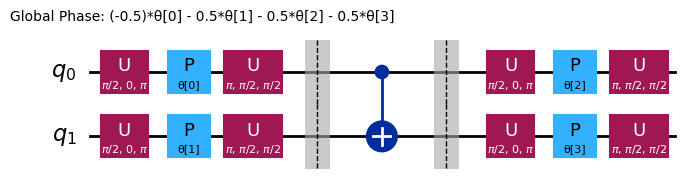

In [5]:
from qiskit.circuit.library import efficient_su2
ansatz = efficient_su2(hamiltonian.num_qubits,reps=1,insert_barriers=True,su2_gates=['h','rz','y'],entanglement='circular')
ansatz.decompose().draw('mpl') 

In [6]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

In [7]:
service = QiskitRuntimeService(
    token="vVQPyZkLHpBBf2xFtR4C79C2OFJTwrrI9mNZ2_z_jhTO",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/2a11213c61e84a04944ce72c7ccb4e9c:13e4fe87-fd67-4d78-ac7d-6dcdb5b4562c::",
    channel="ibm_cloud"
)
backend = service.least_busy()
backend

<IBMBackend('ibm_marrakesh')>

In [8]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


In [9]:
target = backend.target
pm = generate_preset_pass_manager(target=target,optimization_level=3)


In [10]:
ansatz_isa = pm.run(ansatz) 
ansatz_isa

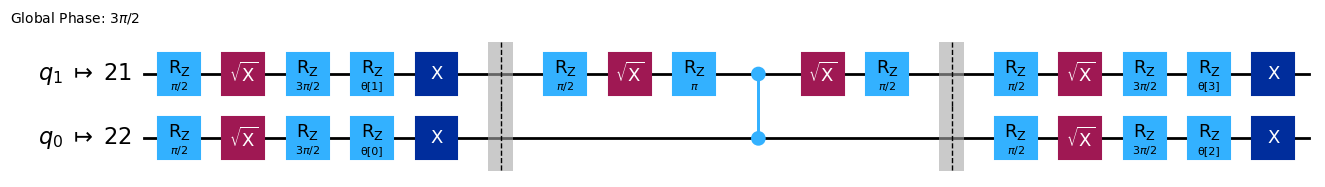

In [11]:
ansatz_isa.draw('mpl')

In [12]:
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)
hamiltonian_isa

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZYIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXXIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[ 0.398 +0.j, -0.398 +0.j, -0.0113+0.j,  0.181 +0.j])

In [13]:
from qiskit_ibm_runtime import Session,EstimatorV2

In [14]:
def cost_func(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")
 
    return energy
 
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
x0 = 2 * np.pi * np.random.random(2)
with Session(backend=backend) as session:
    estimator = EstimatorV2(mode=session)
    estimator.options.default_shots = 100
 
    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 50},
    )

RequestsApiError: '400 Client Error: Bad Request for url: https://us-east.quantum-computing.cloud.ibm.com/sessions. {"errors":[{"code":1352,"message":"You are not authorized to run a session when using the open plan.","solution":"Create an instance of a different plan type or use a different [execution mode](https://quantum.cloud.ibm.com/docs/guides/execution-modes).","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"358d0ffb-132d-4938-a2e3-be673d1f96a2"}\n'

C:\Users\Admin\AppData\Local\Temp\ipykernel_15800\1756326887.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


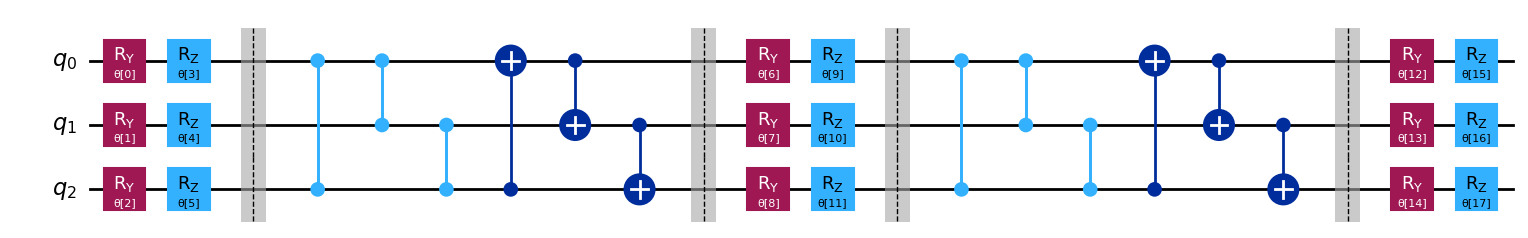

In [27]:
from qiskit.circuit.library import TwoLocal

ansatz = TwoLocal(
    num_qubits=3,
    rotation_blocks=['ry','rz'],
    entanglement='circular',
    entanglement_blocks=['cz','cx'],
    reps=2,
    insert_barriers=True
)
random = np.random.random(ansatz.num_parameters)
ansatz.assign_parameters(random)
ansatz.decompose().draw('mpl')

In [24]:
ansatz.parameters[0]

ParameterVectorElement(θ[0])

<h4>Day 19</h4>

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter
import numpy as np
import matplotlib.pyplot as plt

In [36]:
hamiltonian = SparsePauliOp.from_list([('Z',1)])
hamiltonian 

SparsePauliOp(['Z'],
              coeffs=[1.+0.j])

In [37]:
theta = Parameter('0')
ansatz = QuantumCircuit(1) 
ansatz.rx(theta,0) 
estimator = StatevectorEstimator()
angles = np.linspace(0,2*np.pi,50) 
energies = [] 

for angle in angles:
    job = estimator.run([(ansatz,hamiltonian,[angle])])
    result = job.result()
    ev = result[0].data.evs.item()
    energies.append(ev)
print(energies)

[1.0, 0.991790013823246, 0.9672948630390296, 0.9269167573460217, 0.8713187041233894, 0.8014136218679566, 0.7183493500977276, 0.6234898018587336, 0.5183925683105252, 0.40478334312239395, 0.2845275866310326, 0.15959989503337935, 0.03205157757165544, -0.09602302590768164, -0.22252093395631428, -0.3453650544213076, -0.46253829024083504, -0.5721166601221694, -0.6723008902613165, -0.7614459583691342, -0.8380881048918405, -0.9009688679024191, -0.9490557470106685, -0.9815591569910654, -0.9979453927503363, -0.9979453927503363, -0.9815591569910656, -0.9490557470106689, -0.9009688679024193, -0.8380881048918408, -0.7614459583691346, -0.6723008902613169, -0.5721166601221699, -0.46253829024083537, -0.3453650544213081, -0.22252093395631467, -0.0960230259076823, 0.03205157757165494, 0.15959989503337846, 0.28452758663103206, 0.4047833431223929, 0.5183925683105245, 0.6234898018587333, 0.7183493500977272, 0.8014136218679565, 0.871318704123389, 0.9269167573460216, 0.9672948630390292, 0.991790013823246, 1.

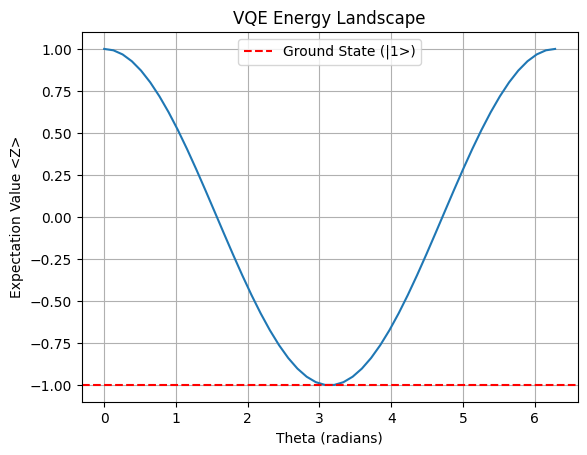

In [38]:
plt.plot(angles, energies)
plt.xlabel('Theta (radians)')
plt.ylabel('Expectation Value <Z>')
plt.title('VQE Energy Landscape')
plt.grid(True)
plt.axhline(y=-1, color='r', linestyle='--', label='Ground State (|1>)')
plt.legend()
plt.show()

In [ ]:
ansatz = QuantumCircuit(2)
ansatz.h(0)
ansatz.cx(0,1)
hamiltonian = SparsePauliOp.from_list([('ZZ',1)]) 

outcomes = [] 
for i in range(10):
    estimator = StatevectorEstimator()
    job = estimator.run([(ansatz,hamiltonian)])
    result = job.result()
    outcomes.append(result[0].data.evs.item()) 
print(outcomes)

[0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998, 0.9999999999999998]


<h4>Day 20</h4>

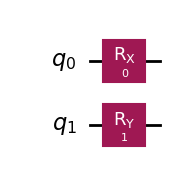

In [47]:
theta1,theta2 = Parameter('0'),Parameter('1')
ansatz = QuantumCircuit(2)
ansatz.rx(theta1,0)
ansatz.ry(theta2,1)
ansatz.draw('mpl')

In [ ]:
hamiltonian = SparsePauliOp.from_list([("ZZ", 1)])
initial_guess = np.random.random(1) * 2 * np.pi
